In [1]:
!pip install d2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.9 MB/s eta 0:00:00


# 1. ResNet

In [2]:
from d2l import torch as d2l

In [3]:
import torch
from torch import nn
from torch.nn import functional as F

class Residual(nn.Module):  #@save
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [4]:
import torch
import torchvision
from torchvision import transforms
def load_data_fashion_mnist_gpu(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory.

    Defined in :numref:`sec_utils`"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="./data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="./data", train=False, transform=trans, download=True)
    return (torch.utils.data.DataLoader(mnist_train, 
                                        batch_size, 
                                        shuffle=True, # DDP need to use DistributedSampler
                                        num_workers=get_dataloader_workers(),
                                        pin_memory=True, # pin_memory=True can speed up data transfer to GPU
                                        prefetch_factor=2, # 每个worker预取2个batch的数据 2~4
                                        persistent_workers=True, #保持worker进程存活,适用于epoch较多时
                                        ), 

            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                                        num_workers=get_dataloader_workers()))

def get_dataloader_workers():
    """Use 4 processes to read the data.

    Defined in :numref:`sec_utils`"""
    return 4

In [5]:
# 残差块
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))  #第一个块不改变高度和宽度,即没有 1*1 卷积
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

在输出通道数为64、步幅为2的$7 \times 7$卷积层后，接步幅为2的$3 \times 3$的最大汇聚层

In [16]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [17]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))
# ResNet-18

In [18]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

In [19]:
# 观察一下每个模块输出的形状
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


loss 0.022, train acc 0.993, test acc 0.873
2864.1 examples/sec on cuda


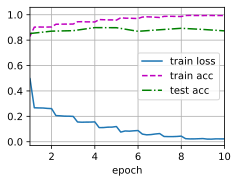

In [20]:
lr, num_epochs, batch_size = 0.05, 10, 256
net=nn.DataParallel(net)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iter, test_iter = load_data_fashion_mnist_gpu(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

In [77]:
net

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (1): DenseBlock(
    (net): Sequential(
      (0): Sequential(
        (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU()
        (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1): Sequential(
        (0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU()
        (2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (2): Sequential(
        (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU()
        (2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

## 在ResNet的后续版本中，作者将“卷积层、批量规范化层和激活层”架构更改为“批量规范化层、激活层和卷积层”架构。请尝试做这个改进。

In [2]:
import torch
from torch import nn
from torch.nn import functional as F

class Residual_pro(nn.Module):  #@save
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(input_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = self.conv1(F.relu(self.bn1(X)))
        Y = self.conv2(F.relu(self.bn2(Y)))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return Y

In [3]:
# 残差块
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual_pro(input_channels, num_channels,
                                use_1x1conv=True, strides=2))  #第一个块不改变高度和宽度,即没有 1*1 卷积
        else:
            blk.append(Residual_pro(num_channels, num_channels))
    return blk

In [4]:
b1p = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

效果不好可能是层数??

In [16]:
b2p = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3p = nn.Sequential(*resnet_block(64, 128, 2))

b4p = nn.Sequential(*resnet_block(128, 256, 2))
b5p = nn.Sequential(*resnet_block(256, 256, 1))

b6p = nn.Sequential(*resnet_block(256, 512, 2))
b7p = nn.Sequential(*resnet_block(512, 512, 1))

# ResNet_proposed

In [17]:
net_p = nn.Sequential(b1p, b2p, b3p, b4p, b5p, b6p, b7p,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

In [18]:
# 观察一下每个模块输出的形状
X = torch.rand(size=(1, 1, 224, 224))
for layer in net_p:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 256, 7, 7])
Sequential output shape:	 torch.Size([1, 512, 4, 4])
Sequential output shape:	 torch.Size([1, 512, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


In [ ]:
lr, num_epochs, batch_size = 0.5, 10, 256
net_p=nn.DataParallel(net_p)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iter, test_iter = load_data_fashion_mnist_gpu(batch_size, resize=96)
d2l.train_ch6(net_p, train_iter, test_iter, num_epochs, lr, device)

----
## 尝试通道数的骤降

In [41]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device, weight_decay):
    """Train a model with a GPU (defined in Chapter 6).

    Defined in :numref:`sec_utils`"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=weight_decay)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

In [19]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [7]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True)) 
#承接上面的 b1 所以是 64.
b3 = nn.Sequential(*resnet_block(64, 384, 2))
b4 = nn.Sequential(*resnet_block(384, 512, 2))
b5 = nn.Sequential(*resnet_block(512, 32, 2))
b6 = nn.Sequential(*resnet_block(32, 48, 4))

In [36]:
net = nn.Sequential(b1, b2, b3, b4, b5, b6, 
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(48, 10))

In [38]:
# 观察一下每个模块输出的形状
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 384, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 32, 7, 7])
Sequential output shape:	 torch.Size([1, 48, 4, 4])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 48, 1, 1])
Flatten output shape:	 torch.Size([1, 48])
Linear output shape:	 torch.Size([1, 10])


loss 0.039, train acc 0.986, test acc 0.885
1459.3 examples/sec on cuda


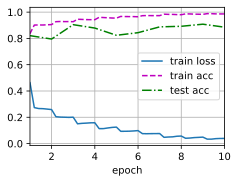

In [39]:
lr, num_epochs, batch_size = 0.03, 10, 256
net=nn.DataParallel(net)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iter, test_iter = load_data_fashion_mnist_gpu(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

0.873->0.885, 貌似是要好一点?

----
**使用weight_decay**

写了保存checkpoint的函数不用wbd!

In [26]:
def save_checkpoint(epoch, net, optimizer, checkpoint_path):
    checkpoint_path=checkpoint_path if isinstance(checkpoint_path,str) else 'checkpoint.pth'
    # 待添加功能:输出路径 
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': net.module.state_dict() if isinstance(net,nn.DataParallel) \
                          else net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }                        
    torch.save(checkpoint, checkpoint_path)
    return f'save checkpoint at epoch {epoch}'
    
def train_GPU_save(net, train_iter, test_iter, num_epochs, lr, device, weight_decay=0, 
              save_checkpoints: str =True, use_checkpoints: str =None,
              save_net: str =True,
             ):
    """
    Train a model with a GPU .
    You can save checkpoints and the net . It's stronger.

    """
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)

    optimizer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=weight_decay)
    loss = nn.CrossEntropyLoss()
    start_epoch=0 #用于使用checkpoint之后可以增量

    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)

    best_test_acc = 0.0  #用于保存网络时选择最优的网络
    if save_net:
        # 确定模型保存路径：若 save_net 是字符串则用作路径，否则使用默认文件名
        best_model_path = save_net if isinstance(save_net, str) else 'best_model.pth'

    if use_checkpoints:
        try:
            checkpoint = torch.load(use_checkpoints, weights_only=True)
            if isinstance(net, nn.DataParallel):
                net.module.load_state_dict(checkpoint['model_state_dict'])
            else:
                net.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch=checkpoint['epoch']+1
            print('Use checkpoint successfully!')
        except FileNotFoundError:
            print('ATTENTION: There is not the checkpoint.')
        except Exception:
            raise
    
    net.to(device)
    status='No saved checkpoints' #防止没有调用save_checkpoint函数时没有status变量
    for epoch in range(start_epoch,num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        
        if epoch%round(num_epochs*0.25)==0 and save_checkpoints:
           status=save_checkpoint(epoch, net, optimizer, save_checkpoints)
        
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))

        if save_net:
            if test_acc > best_test_acc:
                best_test_acc = test_acc
                # 处理 DataParallel 包装的模型
                model_to_save = net.module if isinstance(net, nn.DataParallel) else net
                torch.save(model_to_save.state_dict(), best_model_path)
                print(f'Best model saved with test acc {test_acc:.3f} to {best_model_path}')

        
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec \n'
          f'total time:{timer.sum():.4f} sec '
          f'on {str(device)}')
    print(status)

loss 0.045, train acc 0.985, test acc 0.891
1448.2 examples/sec 
total time:414.3071 sec on cuda


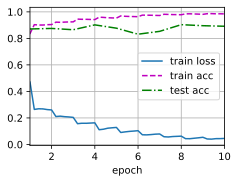

In [9]:
net = nn.Sequential(b1, b2, b3, b4, b5, b6, 
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(48, 10))

lr, num_epochs, batch_size = 0.03, 10, 256
net=nn.DataParallel(net)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iter, test_iter = load_data_fashion_mnist_gpu(batch_size, resize=96)
train_GPU_save(net, train_iter, test_iter, num_epochs, lr, device, weight_decay=1e-3)

loss 0.045, train acc 0.985, test acc 0.908
15144.5 examples/sec 
total time:39.6185 sec on cuda


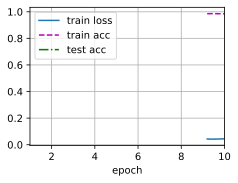

In [10]:
train_GPU_save(net, train_iter, test_iter, num_epochs, lr, device, 
               weight_decay=1e-3, use_checkpoints='checkpoint.pth')

看上去结果还可以,和原来的模型相比准确率没有下降,甚至略有上升.  
但是加了一层,试试不加呢?

In [20]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True)) 
#承接上面的 b1 所以是 64.
b3 = nn.Sequential(*resnet_block(64, 384, 2))
b4 = nn.Sequential(*resnet_block(384, 16, 4))
b5 = nn.Sequential(*resnet_block(16, 32, 2))

loss 0.062, train acc 0.980, test acc 0.888
2230.7 examples/sec 
total time:268.9781 sec on cuda
save checkpoint at epoch 8


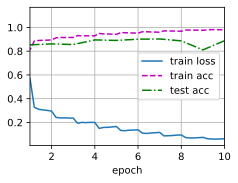

In [21]:
net = nn.Sequential(b1, b2, b3, b4, b5, 
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(32, 10))

lr, num_epochs, batch_size = 0.03, 10, 256
net=nn.DataParallel(net)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iter, test_iter = load_data_fashion_mnist_gpu(batch_size, resize=96)
train_GPU_save(net, train_iter, test_iter, num_epochs, lr, device,
               weight_decay=1e-3, save_checkpoints='b5.pth')

Best model saved with test acc 0.883 to best_model.pth
loss 0.064, train acc 0.979, test acc 0.883
25476.9 examples/sec 
total time:23.5508 sec on cuda
No saved checkpoints


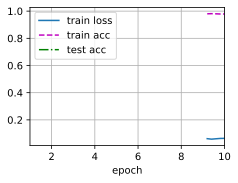

In [28]:
train_GPU_save(net, train_iter, test_iter, num_epochs, lr, device,
               weight_decay=1e-3, use_checkpoints='b5.pth')

# 2. DenseNet

In [6]:
import torch
from torch import nn
from d2l import torch as d2l


def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1))

In [7]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                num_channels * i + input_channels, num_channels))
            # 后面拼接每次都会拼上 num_channels 个通道
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

In [8]:
blk = DenseBlock(2, 3, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

In [9]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

In [10]:
blk = transition_block(23, 10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

In [11]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [12]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

In [13]:
net_d = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

loss 0.098, train acc 0.965, test acc 0.882
2580.6 examples/sec on cuda


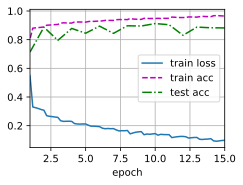

In [14]:
lr, num_epochs, batch_size = 0.1, 15, 256
net_d=nn.DataParallel(net_d)
device=torch.device('cuda')
train_iter, test_iter = load_data_fashion_mnist_gpu(batch_size, resize=96)
d2l.train_ch6(net_d, train_iter, test_iter, num_epochs, lr, device)

额,结果不太稳定

In [86]:
torch.save(net_d.module.state_dict(), '../net_d.pth')

In [75]:
net_d.module[1].net

Sequential(
  (0): Sequential(
    (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU()
    (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (1): Sequential(
    (0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU()
    (2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (2): Sequential(
    (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU()
    (2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (3): Sequential(
    (0): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU()
    (2): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [85]:
net_d

DataParallel(
  (module): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (1): DenseBlock(
      (net): Sequential(
        (0): Sequential(
          (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (1): Sequential(
          (0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (2): Sequential(
          (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
         

## 为什么我们在过渡层使用平均汇聚层而不是最大汇聚层？
貌似最大汇聚层也没有太差?

In [93]:
net_d_max = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveMaxPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

loss 0.049, train acc 0.984, test acc 0.893
2737.0 examples/sec on cuda


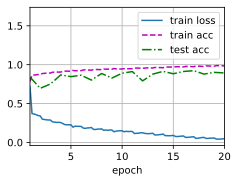

In [94]:
lr, num_epochs, batch_size = 0.1, 20, 256
net_d_max=nn.DataParallel(net_d_max)
device=torch.device('cuda')
train_iter, test_iter = load_data_fashion_mnist_gpu(batch_size, resize=96)
d2l.train_ch6(net_d_max, train_iter, test_iter, num_epochs, lr, device)

In [96]:
net_d_max

DataParallel(
  (module): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (1): DenseBlock(
      (net): Sequential(
        (0): Sequential(
          (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (1): Sequential(
          (0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (2): Sequential(
          (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
         